##Doing the same ML Pipeline as the Tree Based ones, but with Logistic Regression


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv('../bank-additional-full.csv', sep=';')


df = df.drop('duration', axis=1) 

#X are the features and y is the target
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

In [3]:
categorical_cols = X.select_dtypes(include='object').columns 
numeric_cols = X.select_dtypes(exclude='object').columns

print("Categorical columns:", categorical_cols.tolist())
print("Numerical columns:", numeric_cols.tolist())

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [4]:
preprocessor = ColumnTransformer( #Using the same one hot encoder as before and 
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols)  #also using Standard Scalar for numeric variables for Logistic Regression
    ]
) 

In [5]:
#loading in the logistic regression with regularization
lr = LogisticRegression(
    random_state=1,
    max_iter=1000,  
    class_weight='balanced',  
    n_jobs=-1,
    solver='saga'  #sage supports both l1 and l2
)


pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lr)
])

In [6]:
#hyper parameter grid, once again not too big because I don't have much computational resources
param_grid = {
    
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    
    #regularization type
    'model__penalty': ['l1', 'l2', 'elasticnet'],
    
    #l1 ratio only for elastic net
    'model__l1_ratio': [0.3, 0.5, 0.7],
    
    # Solver (saga supports all penalties)
    'model__solver': ['saga']
}



In [7]:
#splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Class distribution in training: {y_train.value_counts().to_dict()}")

Training set size: 32950
Test set size: 8238
Class distribution in training: {0: 29238, 1: 3712}


In [8]:

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='roc_auc',  #this isetter for imbalanced data
    return_train_score=True
)

print("\n" + "="*70)
print("STARTING HYPERPARAMETER TUNING WITH 5-FOLD CV")
print("="*70)

#fit the grid search
grid_search.fit(X_train, y_train)


STARTING HYPERPARAMETER TUNING WITH 5-FOLD CV
Fitting 5 folds for each of 54 candidates, totalling 270 fits


/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/skle

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         Index(['age', 'duration', 'campaign', 'pdays', 'p...
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))])),
                                       ('model',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           n_jobs=-1,
                                                           random_state=1,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'model__l1_ratio': [0.3, 0.5, 0.7],
                         'model__penalty': ['l1', 'l2', 'elasticnet'],
                         'model__solver': ['saga']},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [9]:

print("\n" + "="*70)
print("BEST HYPERPARAMETERS")
print("="*70)
print("Best parameters:", grid_search.best_params_)
print(f"Best CV ROC-AUC score: {grid_search.best_score_:.4f}")

#showing the top 5 parameter combos
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nTop 5 parameter combinations:")
top_5 = cv_results.nsmallest(5, 'rank_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'mean_train_score']
]
for idx, row in top_5.iterrows():
    print(f"\n{row['params']}")
    print(f"  CV ROC-AUC: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
    print(f"  Train ROC-AUC: {row['mean_train_score']:.4f}")


BEST HYPERPARAMETERS
Best parameters: {'model__C': 0.1, 'model__l1_ratio': 0.3, 'model__penalty': 'l1', 'model__solver': 'saga'}
Best CV ROC-AUC score: 0.9380

Top 5 parameter combinations:

{'model__C': 0.1, 'model__l1_ratio': 0.3, 'model__penalty': 'l1', 'model__solver': 'saga'}
  CV ROC-AUC: 0.9380 (+/- 0.0054)
  Train ROC-AUC: 0.9391

{'model__C': 0.1, 'model__l1_ratio': 0.5, 'model__penalty': 'l1', 'model__solver': 'saga'}
  CV ROC-AUC: 0.9380 (+/- 0.0054)
  Train ROC-AUC: 0.9391

{'model__C': 0.1, 'model__l1_ratio': 0.7, 'model__penalty': 'l1', 'model__solver': 'saga'}
  CV ROC-AUC: 0.9380 (+/- 0.0054)
  Train ROC-AUC: 0.9391

{'model__C': 0.1, 'model__l1_ratio': 0.7, 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
  CV ROC-AUC: 0.9379 (+/- 0.0054)
  Train ROC-AUC: 0.9391

{'model__C': 0.1, 'model__l1_ratio': 0.5, 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
  CV ROC-AUC: 0.9379 (+/- 0.0055)
  Train ROC-AUC: 0.9392


In [10]:
#getting best model
best_model = grid_search.best_estimator_

#making predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

In [11]:

print("\n" + "="*70)
print("TEST SET PERFORMANCE")
print("="*70)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


TEST SET PERFORMANCE
Accuracy: 0.8619
ROC-AUC: 0.9347

Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.86      0.92      7310
         Yes       0.44      0.87      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.87      0.75      8238
weighted avg       0.92      0.86      0.88      8238


Confusion Matrix:
[[6291 1019]
 [ 119  809]]


✅ Saved: LR_roc_curve.png


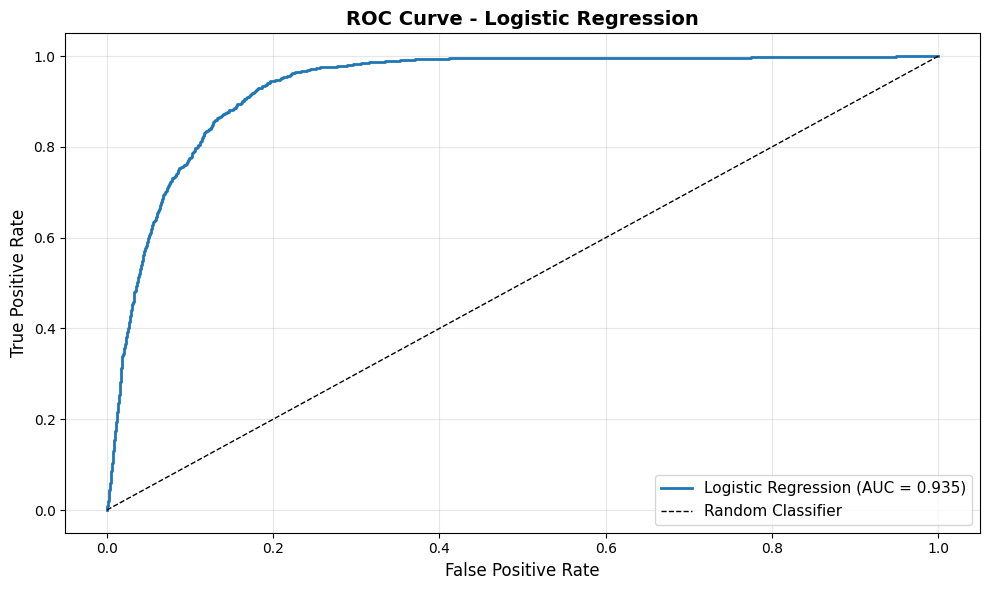

In [12]:
#calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

#plotting roc curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, linewidth=2, 
         label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('output/LR_roc_curve.png', dpi=300, bbox_inches='tight')
print("✅ Saved: LR_roc_curve.png")
plt.show()

In [13]:
#getting feature names after preprocessing
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

#getting the coefficiants
coefficients = best_model.named_steps['model'].coef_[0]

#create dataframe
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

#displaying summary
print("="*70)
print("FEATURE IMPORTANCE (LOGISTIC REGRESSION COEFFICIENTS)")
print("="*70)
print(f"\nTotal features: {len(feature_names)}")
print(f"Positive coefficients (increase subscription): {sum(coefficients > 0)}")
print(f"Negative coefficients (decrease subscription): {sum(coefficients < 0)}")
print(f"Coefficient range: {coefficients.min():.4f} to {coefficients.max():.4f}")

FEATURE IMPORTANCE (LOGISTIC REGRESSION COEFFICIENTS)

Total features: 63
Positive coefficients (increase subscription): 23
Negative coefficients (decrease subscription): 22
Coefficient range: -2.9719 to 1.8267


In [14]:
#top 20 featurs shown
top_n = 20
top_features = feature_importance.head(top_n)

print(f"\nTop {top_n} Most Important Features:")
print("="*70)
for i, row in enumerate(top_features.itertuples(), 1):
    direction = "📈 Positive" if row.coefficient > 0 else "📉 Negative"
    print(f"{i:>2}. {row.feature:<45} {row.coefficient:>8.4f} ({direction})")


Top 20 Most Important Features:
 1. num__emp.var.rate                              -2.9719 (📉 Negative)
 2. cat__month_mar                                  1.8267 (📈 Positive)
 3. num__duration                                   1.8165 (📈 Positive)
 4. num__cons.price.idx                             1.0897 (📈 Positive)
 5. num__euribor3m                                  0.9714 (📈 Positive)
 6. cat__month_may                                 -0.9553 (📉 Negative)
 7. cat__month_aug                                  0.8188 (📈 Positive)
 8. cat__month_jun                                 -0.7631 (📉 Negative)
 9. cat__month_nov                                 -0.6487 (📉 Negative)
10. cat__job_retired                                0.4783 (📈 Positive)
11. cat__poutcome_failure                          -0.4178 (📉 Negative)
12. cat__contact_telephone                         -0.3774 (📉 Negative)
13. cat__default_unknown                           -0.3206 (📉 Negative)
14. cat__job_blue-collar       

✅ Saved: LR_feature_importance_top20.png


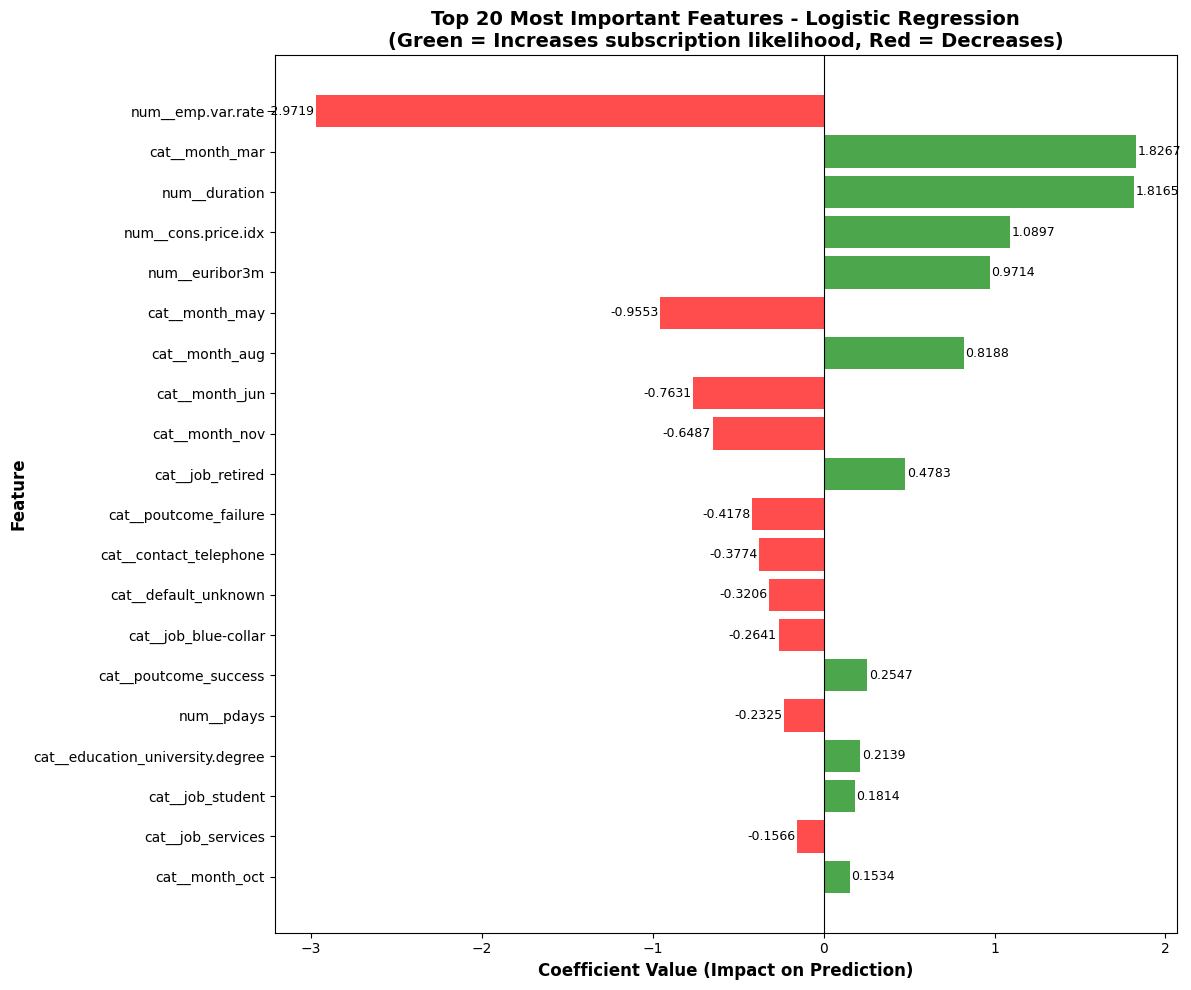

In [15]:
#plotting
plt.figure(figsize=(12, 10))
colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
bars = plt.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)

#formatting
plt.yticks(range(len(top_features)), top_features['feature'], fontsize=10)
plt.xlabel('Coefficient Value (Impact on Prediction)', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Most Important Features - Logistic Regression\n(Green = Increases subscription likelihood, Red = Decreases)', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.gca().invert_yaxis()

#adding value labels
for i, (bar, val) in enumerate(zip(bars, top_features['coefficient'])):
    x_pos = val + (0.01 if val > 0 else -0.01)
    ha = 'left' if val > 0 else 'right'
    plt.text(x_pos, i, f'{val:.4f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig(f'output/LR_feature_importance_top{top_n}.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: LR_feature_importance_top{top_n}.png")
plt.show()

In [17]:
#saving
feature_importance.to_csv('output/LR_all_feature_importance.csv', index=False)
print(f" Saved: LR_all_feature_importance.csv (all {len(feature_importance)} features)")


print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Strongest positive feature: {feature_importance.loc[feature_importance['coefficient'].idxmax(), 'feature']}")
print(f"Strongest negative feature: {feature_importance.loc[feature_importance['coefficient'].idxmin(), 'feature']}")


categorical_count = sum(1 for f in top_features['feature'] if 'cat__' in f)
numerical_count = sum(1 for f in top_features['feature'] if 'num__' in f)


 Saved: LR_all_feature_importance.csv (all 63 features)

SUMMARY
Strongest positive feature: cat__month_mar
Strongest negative feature: num__emp.var.rate
